In [1]:
import pandas as pd

In [2]:
senti=pd.read_csv('fear_greed_index.csv')

In [3]:
trades=pd.read_csv('historical_data.csv')

In [5]:
senti['date'] = pd.to_datetime(senti['date']).dt.date

senti['classification'] = senti['classification'].replace({
        'Extreme Fear': 'Fear',
        'Extreme Greed': 'Greed'
    })

In [6]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')
trades['date'] = trades['Timestamp'].dt.date


In [7]:
df = trades.merge(
        senti[['date', 'classification']],
        on='date',
        how='left'
    )

In [10]:
df.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
classification      0
dtype: int64

In [9]:
df = df.sort_values('date')
df['classification'] = df['classification'].fillna(method='ffill')


/tmp/ipykernel_141042/4194499712.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['classification'] = df['classification'].fillna(method='ffill')


In [12]:
    df['abs_size'] = df['Size USD'].abs()

    # Trade direction
    df['is_long'] = df['Side'].str.lower() == 'buy'

    # Trader frequency
    trade_counts = df['Account'].value_counts()
    threshold = trade_counts.median()

    df['trader_freq'] = df['Account'].map(
        lambda x: 'Frequent' if trade_counts[x] > threshold else 'Infrequent'
    )

    # Risk group
    median_size = df['abs_size'].median()
    df['risk_group'] = df['abs_size'].apply(
        lambda x: 'High Risk' if x > median_size else 'Low Risk'
    )

    # Consistency
    pnl_total = df.groupby('Account')['Closed PnL'].sum()
    df['consistency'] = df['Account'].map(
        lambda x: 'Winner' if pnl_total[x] > 0 else 'Loser'
    )

    

In [13]:
df['target'] = (df['Closed PnL'] > 0).astype(int)


In [73]:
    final_df = df[[
        'abs_size',
        'Coin',
        'is_long',
        'classification',
        'trader_freq',
        'risk_group',
        'consistency',
        'target'
    ]]


In [74]:
final_df.isnull().sum()

abs_size          0
Coin              0
is_long           0
classification    0
trader_freq       0
risk_group        0
consistency       0
target            0
dtype: int64

In [75]:
final_df.shape

(211224, 8)

In [76]:
    final_df = pd.get_dummies(final_df, drop_first=True)


In [77]:
X = final_df.drop('target', axis=1)
y = final_df['target']

In [78]:
y.value_counts()

target
0    124355
1     86869
Name: count, dtype: int64

In [79]:

"""
import pandas as pd
import numpy as np

#def preprocess_pipeline(trades_df, sentiment_df):

    # -----------------------------
    # 1. SENTIMENT CLEANING
    # -----------------------------
    senti['date'] = pd.to_datetime(senti['date']).dt.date

    senti['classification'] = senti['classification'].replace({
        'Extreme Fear': 'Fear',
        'Extreme Greed': 'Greed'
    })

    # -----------------------------
    # 2. TRADE DATA CLEANING
    # -----------------------------
    trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')
    trades['date'] = trades['Timestamp'].dt.date

    # -----------------------------
    # 3. MERGE DATA
    # -----------------------------
    df = trades.merge(
        senti[['date', 'classification']],
        on='date',
        how='left'
    )

    # Fill missing sentiment
    df = df.sort_values('date')
    df['classification'] = df['classification'].fillna(method='ffill')

    # -----------------------------
    # 4. FEATURE ENGINEERING
    # -----------------------------

    # Trade size
    df['abs_size'] = df['Size USD'].abs()

    # Trade direction
    df['is_long'] = df['Side'].str.lower() == 'buy'

    # Trader frequency
    trade_counts = df['Account'].value_counts()
    threshold = trade_counts.median()

    df['trader_freq'] = df['Account'].map(
        lambda x: 'Frequent' if trade_counts[x] > threshold else 'Infrequent'
    )

    # Risk group
    median_size = df['abs_size'].median()
    df['risk_group'] = df['abs_size'].apply(
        lambda x: 'High Risk' if x > median_size else 'Low Risk'
    )

    # Consistency
    pnl_total = df.groupby('Account')['Closed PnL'].sum()
    df['consistency'] = df['Account'].map(
        lambda x: 'Winner' if pnl_total[x] > 0 else 'Loser'
    )

    # -----------------------------
    # 5. TARGET
    # -----------------------------
    df['target'] = (df['Closed PnL'] > 0).astype(int)

    # -----------------------------
    # 6. SELECT FINAL FEATURES
    # -----------------------------
    final_df = df[[
        'abs_size',
        'is_long',
        'classification',
        'trader_freq',
        'risk_group',
        'consistency',
        'target'
    ]]

    # -----------------------------
    # 7. ENCODING
    # -----------------------------
    final_df = pd.get_dummies(final_df, drop_first=True)

    return final_df
"""

"\nimport pandas as pd\nimport numpy as np\n\n#def preprocess_pipeline(trades_df, sentiment_df):\n\n    # -----------------------------\n    # 1. SENTIMENT CLEANING\n    # -----------------------------\n    senti['date'] = pd.to_datetime(senti['date']).dt.date\n\n    senti['classification'] = senti['classification'].replace({\n        'Extreme Fear': 'Fear',\n        'Extreme Greed': 'Greed'\n    })\n\n    # -----------------------------\n    # 2. TRADE DATA CLEANING\n    # -----------------------------\n    trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')\n    trades['date'] = trades['Timestamp'].dt.date\n\n    # -----------------------------\n    # 3. MERGE DATA\n    # -----------------------------\n    df = trades.merge(\n        senti[['date', 'classification']],\n        on='date',\n        how='left'\n    )\n\n    # Fill missing sentiment\n    df = df.sort_values('date')\n    df['classification'] = df['classification'].fillna(method='ffill')\n\n    # ---------

In [80]:
X.head()

,abs_size,is_long,Coin_@10,Coin_@100,Coin_@103,Coin_@107,Coin_@109,Coin_@11,Coin_@112,Coin_@113,...,Coin_kBONK,Coin_kFLOKI,Coin_kNEIRO,Coin_kPEPE,Coin_kSHIB,classification_Greed,classification_Neutral,trader_freq_Infrequent,risk_group_Low Risk,consistency_Winner
83771,137.08,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,True,False
83770,156.39,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,True,False
83769,183.53,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,True,False
39280,6765.20,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
39641,4910.85,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True


In [98]:
X.shape

(211224, 252)

In [99]:
X['classification_Neutral'].value_counts()

classification_Neutral
0    204083
1      7141
Name: count, dtype: int64

In [82]:
X = X.astype(int)

In [83]:
X.head()

,abs_size,is_long,Coin_@10,Coin_@100,Coin_@103,Coin_@107,Coin_@109,Coin_@11,Coin_@112,Coin_@113,...,Coin_kBONK,Coin_kFLOKI,Coin_kNEIRO,Coin_kPEPE,Coin_kSHIB,classification_Greed,classification_Neutral,trader_freq_Infrequent,risk_group_Low Risk,consistency_Winner
83771,137,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,1,0
83770,156,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,1,0
83769,183,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,1,0
39280,6765,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
39641,4910,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1


In [84]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier()


In [85]:
from sklearn.model_selection import train_test_split

In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)


In [87]:
X_train.head()

,abs_size,is_long,Coin_@10,Coin_@100,Coin_@103,Coin_@107,Coin_@109,Coin_@11,Coin_@112,Coin_@113,...,Coin_kBONK,Coin_kFLOKI,Coin_kNEIRO,Coin_kPEPE,Coin_kSHIB,classification_Greed,classification_Neutral,trader_freq_Infrequent,risk_group_Low Risk,consistency_Winner
74948,130,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
35185,7647,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
134500,59,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,1
57330,100,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
51889,1599,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [88]:
clf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [89]:
y_pred=clf.predict(X_test)

In [90]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [91]:
from sklearn.metrics import confusion_matrix

In [92]:
cm=confusion_matrix(y_test, y_pred)

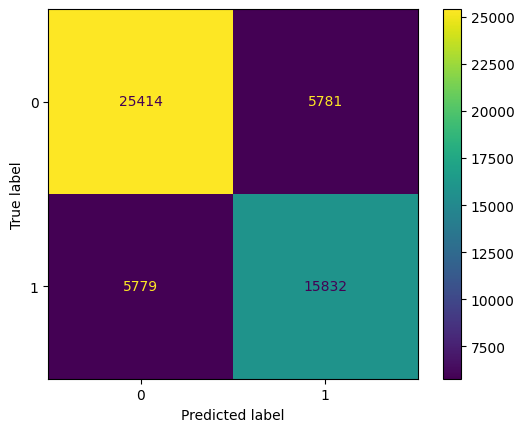

In [93]:
from sklearn.metrics import ConfusionMatrixDisplay
cm_display = ConfusionMatrixDisplay(cm).plot()

In [94]:
from sklearn.metrics import f1_score
f1=f1_score(y_test, y_pred)


In [95]:
print(f1)

0.7325559874143994


In [96]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7810854827102981


In [101]:
print(clf.score(X_test, y_test))

0.7810854827102981


Precision: 0.7325220931846573
Recall: 0.7325898847808986
F1-score: 0.7325559874143994


In [105]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [106]:
y_pred = model.predict(X_test)

In [107]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7482861796008029


In [ ]:
from sklearn.model_selection import GridSearchCV
# Parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Grid Search
grid_search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='f1',   # better than accuracy
    verbose=2
)
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
